# Path Patching Results
Load saved tensors from `results/` and compare the 2B and 12B heatmaps.

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import json
from pathlib import Path

VISUALS_DIR = Path("results/visuals")
VISUALS_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# Gemma 2B
resid_2b = torch.load("results/gemma_2b/path_patch_final_resid.pt", 
                       map_location="cpu").numpy()
with open("results/gemma_2b/baseline_metrics.json") as f:
    baseline_2b = json.load(f)

# Gemma 12B
resid_12b = torch.load("results/gemma_12b/path_patch_final_resid.pt",
                        map_location="cpu").numpy()
with open("results/gemma_12b/baseline_metrics.json") as f:
    baseline_12b = json.load(f)

print(f"2B tensor shape: {resid_2b.shape}")
print(f"12B tensor shape: {resid_12b.shape}")
print(f"2B clean_ld={baseline_2b['clean_ld']:.4f}, corrupt_ld={baseline_2b['corrupt_ld']:.4f}")
print(f"12B clean_ld={baseline_12b['clean_ld']:.4f}, corrupt_ld={baseline_12b['corrupt_ld']:.4f}")

2B tensor shape: (18, 8)
12B tensor shape: (48, 16)
2B clean_ld=0.0115, corrupt_ld=-0.6914
12B clean_ld=0.2227, corrupt_ld=-0.0903


/var/folders/x9/ykzhccfn31j1shpqsnp2_9800000gn/T/ipykernel_35482/3554640662.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


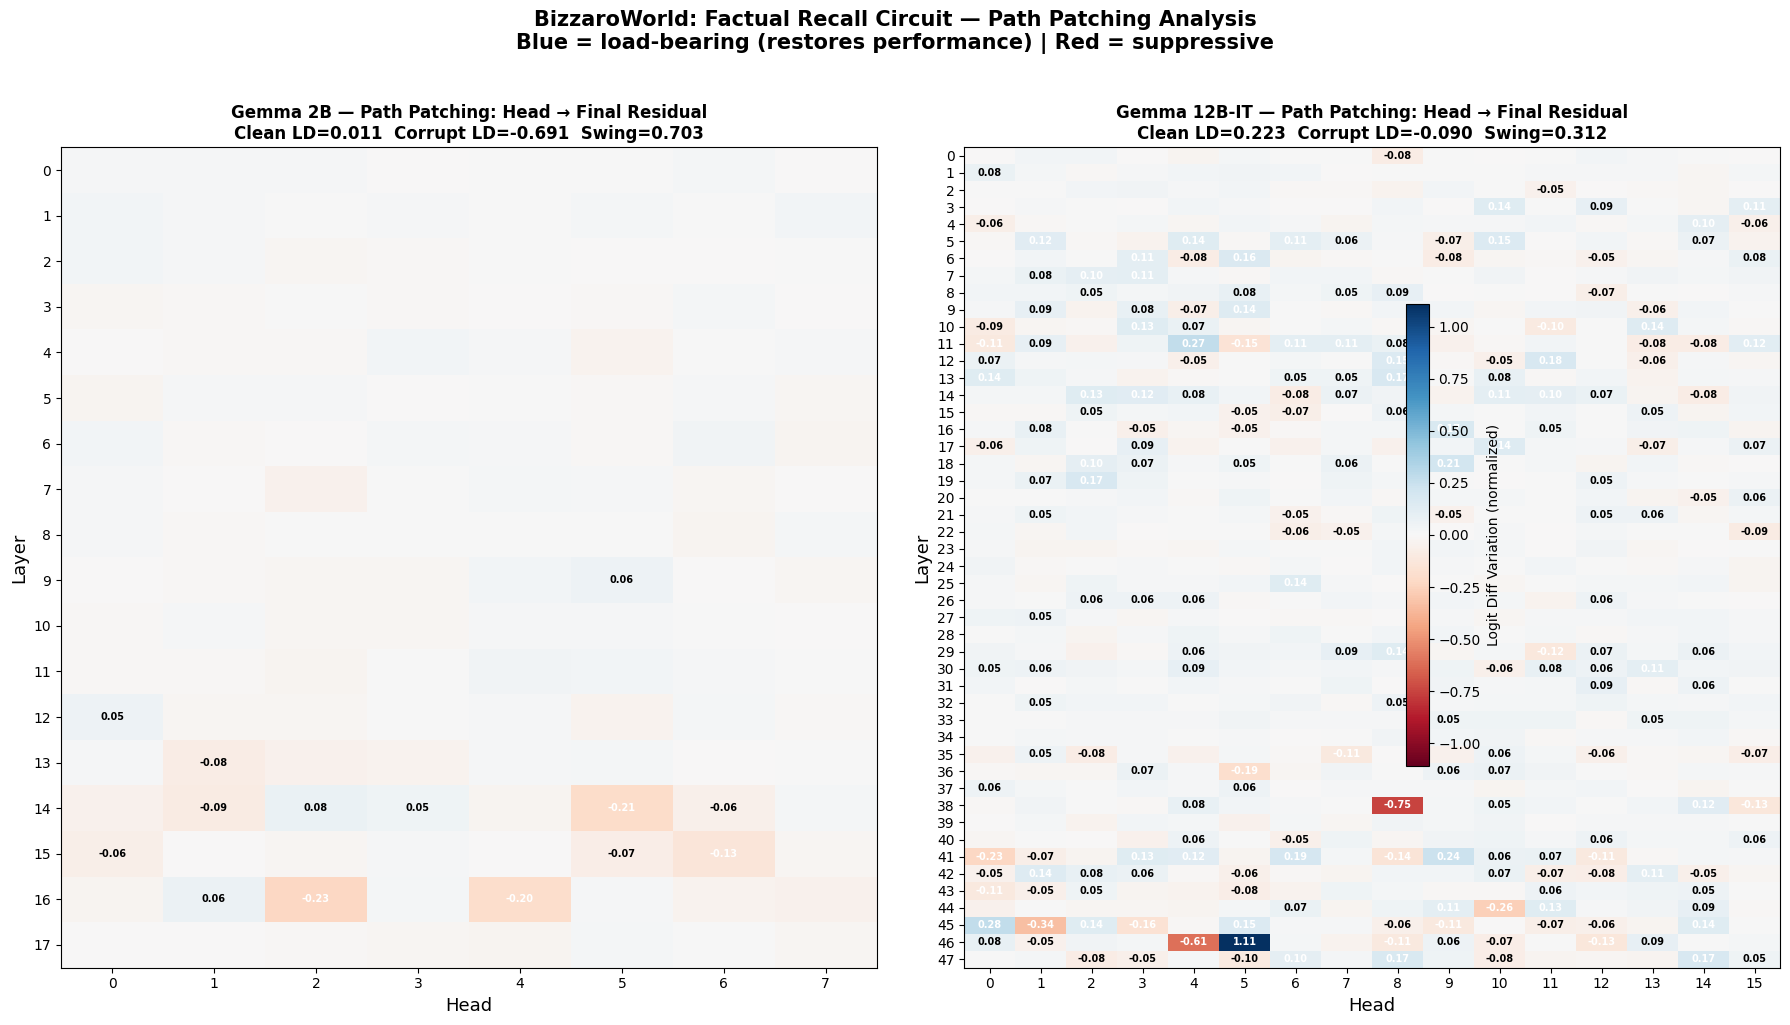

Saved side-by-side heatmap


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# Shared colorscale across both models for fair comparison
vmax = max(abs(resid_2b).max(), abs(resid_12b).max())
vmin = -vmax

for ax, tensor, title, baseline in zip(
    axes,
    [resid_2b, resid_12b],
    ["Gemma 2B — Path Patching: Head → Final Residual",
     "Gemma 12B-IT — Path Patching: Head → Final Residual"],
    [baseline_2b, baseline_12b]
):
    im = ax.imshow(tensor, cmap="RdBu", vmin=vmin, vmax=vmax, 
                   aspect="auto", interpolation="nearest")
    ax.set_xlabel("Head", fontsize=13)
    ax.set_ylabel("Layer", fontsize=13)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xticks(range(tensor.shape[1]))
    ax.set_yticks(range(tensor.shape[0]))
    
    # Annotate cells with values for top candidates
    threshold = 0.05
    for i in range(tensor.shape[0]):
        for j in range(tensor.shape[1]):
            val = tensor[i, j]
            if abs(val) > threshold:
                ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                       fontsize=7, color="white" if abs(val) > 0.1 else "black",
                       fontweight="bold")
    
    subtitle = (f"Clean LD={baseline['clean_ld']:.3f}  "
                f"Corrupt LD={baseline['corrupt_ld']:.3f}  "
                f"Swing={baseline['total_swing']:.3f}")
    ax.set_title(f"{title}\n{subtitle}", fontsize=12, fontweight="bold")

plt.colorbar(im, ax=axes, label="Logit Diff Variation (normalized)", 
             shrink=0.6, pad=0.02)
plt.suptitle("BizzaroWorld: Factual Recall Circuit — Path Patching Analysis\n"
             "Blue = load-bearing (restores performance) | Red = suppressive",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(VISUALS_DIR / "path_patch_heatmap_side_by_side.png", 
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved side-by-side heatmap")

In [4]:
def get_top_heads(tensor, model_name, n=10):
    flat = tensor.flatten()
    top_neg_idx = np.argsort(flat)[:n]   # most negative = most load-bearing
    top_pos_idx = np.argsort(flat)[-n:][::-1]  # most positive = suppressive
    
    print(f"\n{'='*50}")
    print(f"{model_name} — Top load-bearing heads (negative):")
    print(f"{'Layer':>6} {'Head':>6} {'Score':>10}")
    print("-" * 26)
    candidates = []
    for idx in top_neg_idx:
        layer, head = divmod(idx, tensor.shape[1])
        score = tensor[layer, head]
        print(f"{layer:>6} {head:>6} {score:>10.4f}")
        candidates.append((layer, head, score))
    
    print(f"\n{model_name} — Top suppressive heads (positive):")
    print(f"{'Layer':>6} {'Head':>6} {'Score':>10}")
    print("-" * 26)
    for idx in top_pos_idx:
        layer, head = divmod(idx, tensor.shape[1])
        score = tensor[layer, head]
        print(f"{layer:>6} {head:>6} {score:>10.4f}")
    
    return candidates

candidates_2b = get_top_heads(resid_2b, "Gemma 2B", n=10)
candidates_12b = get_top_heads(resid_12b, "Gemma 12B", n=10)


Gemma 2B — Top load-bearing heads (negative):
 Layer   Head      Score
--------------------------
    16      2    -0.2305
    14      5    -0.2051
    16      4    -0.1973
    15      6    -0.1318
    14      1    -0.0903
    13      1    -0.0791
    15      5    -0.0708
    15      0    -0.0630
    14      6    -0.0576
    14      0    -0.0491

Gemma 2B — Top suppressive heads (positive):
 Layer   Head      Score
--------------------------
    14      2     0.0752
    16      1     0.0640
     9      5     0.0583
    12      0     0.0527
    14      3     0.0518
    11      4     0.0417
     6      6     0.0369
     9      4     0.0339
     1      0     0.0339
    11      5     0.0339

Gemma 12B — Top load-bearing heads (negative):
 Layer   Head      Score
--------------------------
    38      8    -0.7461
    46      4    -0.6133
    45      1    -0.3379
    44     10    -0.2617
    41      0    -0.2314
    36      5    -0.1904
    45      3    -0.1562
    11      5    -0.1504
   

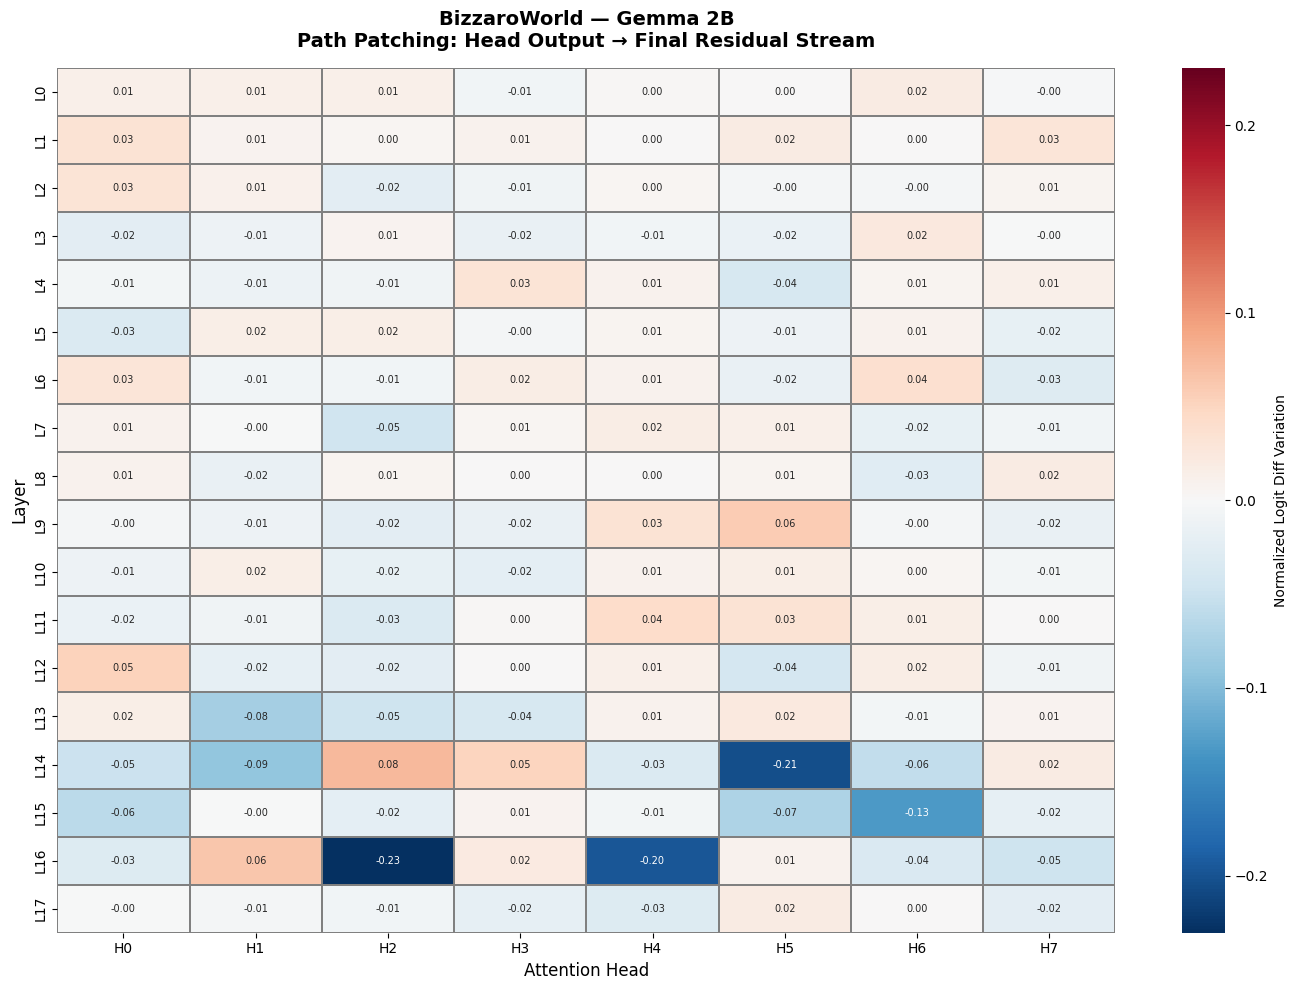

Saved heatmap_2b.png


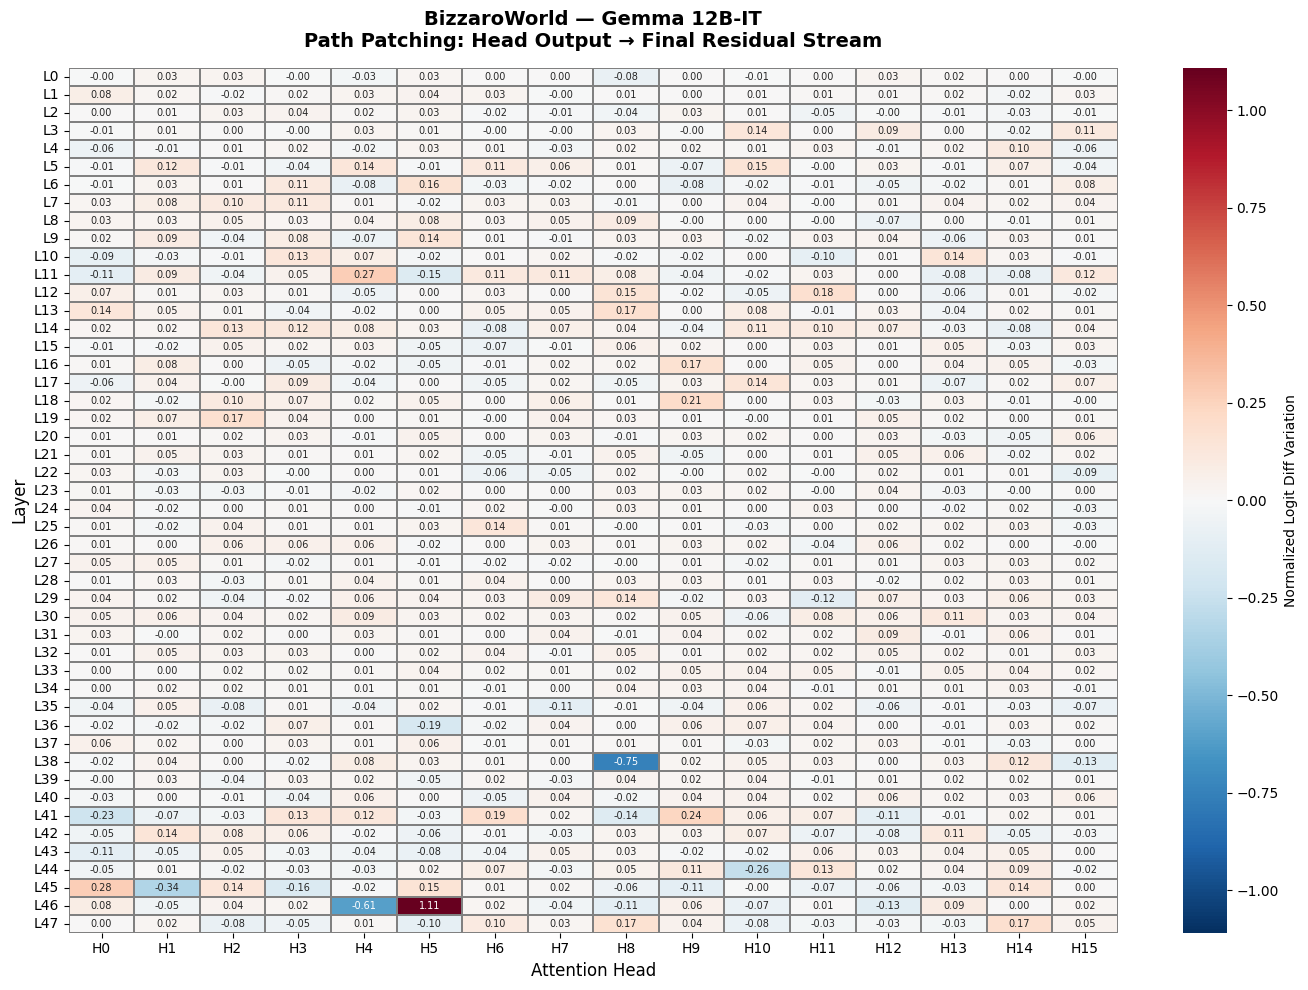

Saved heatmap_12b.png


In [5]:
for tensor, model_name, filename in [
    (resid_2b, "Gemma 2B", "heatmap_2b.png"),
    (resid_12b, "Gemma 12B-IT", "heatmap_12b.png"),
]:
    fig, ax = plt.subplots(figsize=(14, 10))
    vmax = abs(tensor).max()
    
    sns.heatmap(
        tensor,
        ax=ax,
        cmap="RdBu_r",
        center=0,
        vmin=-vmax,
        vmax=vmax,
        annot=tensor.shape[1] <= 16,  # annotate if not too many heads
        fmt=".2f",
        annot_kws={"size": 7},
        xticklabels=[f"H{i}" for i in range(tensor.shape[1])],
        yticklabels=[f"L{i}" for i in range(tensor.shape[0])],
        linewidths=0.3,
        linecolor="gray",
        cbar_kws={"label": "Normalized Logit Diff Variation"}
    )
    
    ax.set_title(f"BizzaroWorld — {model_name}\nPath Patching: Head Output → Final Residual Stream",
                fontsize=14, fontweight="bold", pad=15)
    ax.set_xlabel("Attention Head", fontsize=12)
    ax.set_ylabel("Layer", fontsize=12)
    
    plt.tight_layout()
    plt.savefig(VISUALS_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {filename}")

In [6]:
# Take top N most negative heads as receiver candidates
N = 5

receiver_2b = [(int(l), int(h)) for l, h, s in candidates_2b[:N]]
receiver_12b = [(int(l), int(h)) for l, h, s in candidates_12b[:N]]

print("="*50)
print("NEXT RUN COMMANDS:")
print()
print("For Gemma 2B — add to run_experiments.py or pass as args:")
print(f"receiver_heads_2b = {receiver_2b}")
receiver_str_2b = " ".join([f"{l}:{h}" for l, h in receiver_2b])
print(f"CLI: python run_experiments.py --model gemma_2b --receiver-heads {receiver_str_2b} --receiver-input q")
print()
print("For Gemma 12B:")
print(f"receiver_heads_12b = {receiver_12b}")
receiver_str_12b = " ".join([f"{l}:{h}" for l, h in receiver_12b])
print(f"CLI: python run_experiments.py --model gemma_12b --receiver-heads {receiver_str_12b} --receiver-input q")

# Save receiver heads to json for automated pickup
import json
with open(VISUALS_DIR / "receiver_heads.json", "w") as f:
    json.dump({
        "gemma_2b": receiver_2b,
        "gemma_12b": receiver_12b,
    }, f, indent=2)
print(f"\nSaved receiver_heads.json to {VISUALS_DIR}")

NEXT RUN COMMANDS:

For Gemma 2B — add to run_experiments.py or pass as args:
receiver_heads_2b = [(16, 2), (14, 5), (16, 4), (15, 6), (14, 1)]
CLI: python run_experiments.py --model gemma_2b --receiver-heads 16:2 14:5 16:4 15:6 14:1 --receiver-input q

For Gemma 12B:
receiver_heads_12b = [(38, 8), (46, 4), (45, 1), (44, 10), (41, 0)]
CLI: python run_experiments.py --model gemma_12b --receiver-heads 38:8 46:4 45:1 44:10 41:0 --receiver-input q

Saved receiver_heads.json to results/visuals


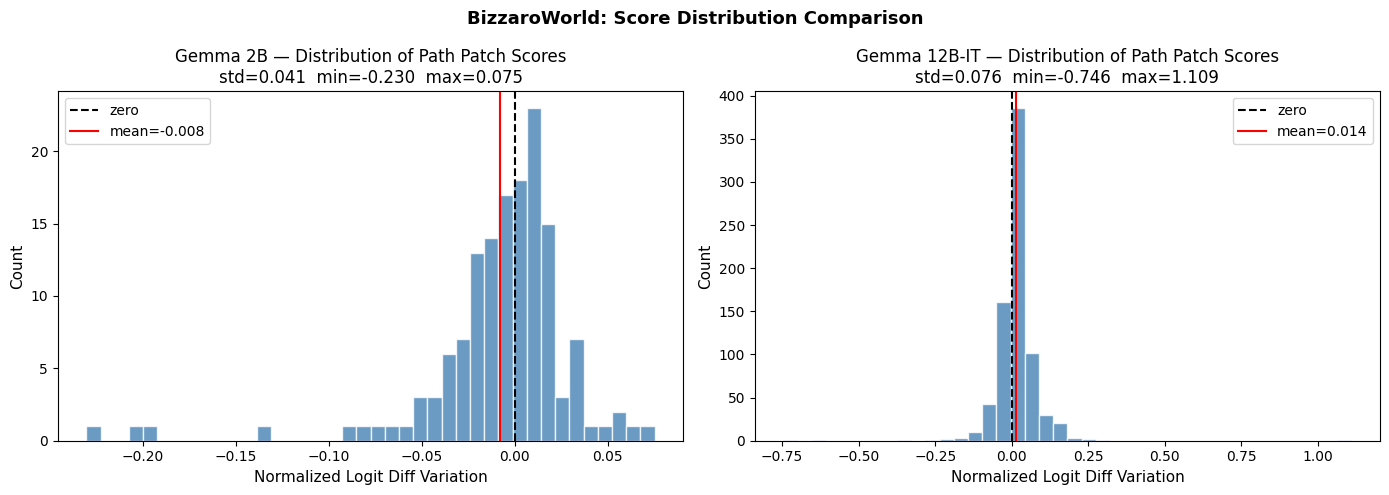

Saved score distributions


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, tensor, model_name in [
    (axes[0], resid_2b, "Gemma 2B"),
    (axes[1], resid_12b, "Gemma 12B-IT"),
]:
    flat = tensor.flatten()
    ax.hist(flat, bins=40, color="steelblue", edgecolor="white", alpha=0.8)
    ax.axvline(0, color="black", linestyle="--", linewidth=1.5, label="zero")
    ax.axvline(flat.mean(), color="red", linestyle="-", linewidth=1.5, 
               label=f"mean={flat.mean():.3f}")
    ax.set_xlabel("Normalized Logit Diff Variation", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.set_title(f"{model_name} — Distribution of Path Patch Scores\n"
                 f"std={flat.std():.3f}  min={flat.min():.3f}  max={flat.max():.3f}",
                 fontsize=12)
    ax.legend(fontsize=10)

plt.suptitle("BizzaroWorld: Score Distribution Comparison", 
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(VISUALS_DIR / "score_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved score distributions")